# 01 — Data Generation & Schema Understanding

## Objective
Understand the structure, shape, and quality of the raw fraud
detection data simulating ride transaction fraud on a Bangalore
ride sharing platform.

## What This Notebook Covers
- Schema of each table
- Row counts and column types
- Null value analysis per table
- Duplicate detection
- Target variable distribution — Stage 1 (binary) and Stage 2 (multi-class)
- Fraud signal preview — what makes each fraud type look different
- Key observations before cleaning

## Data Period  : Full Year 2025
## City         : Bangalore
## Tables       : transactions, drivers, users, devices
## Stage 1 Target : is_fraud (0=legitimate, 1=fraud)
## Stage 2 Target : fraud_label (0=legit, 1=driver, 2=user, 3=collusion)

## Why This Project Is Different
Three unique challenges not in any previous project:

1. EXTREME class imbalance — 97% legitimate, 3% fraud.
   Much harder than cancellation prediction's 77/6.5/15.8 split.
   Standard accuracy is completely useless as a metric here.

2. Fraud is DESIGNED to look normal — fraudsters deliberately
   mimic legitimate behavior to avoid detection. The signals
   are subtle, not obvious.

3. Hierarchical architecture — two models chained together.
   Stage 1 detects IF fraud occurred. Stage 2 classifies WHAT
   type of fraud. Plus anomaly detection models that need no
   fraud labels at all.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

# Consistent colors throughout this project
FRAUD_COLORS = {
    0: "#4CAF50",   # Legitimate — green
    1: "#F44336",   # Driver Fraud — red
    2: "#FF9800",   # User Fraud — orange
    3: "#9C27B0",   # Collusion Fraud — purple
}
FRAUD_LABELS = {
    0: "Legitimate",
    1: "Driver Fraud",
    2: "User Fraud",
    3: "Collusion Fraud"
}

print("Libraries loaded ✅")
print(f"\nFraud label colors defined:")
for k, v in FRAUD_LABELS.items():
    print(f"  {k}: {v}")

Libraries loaded ✅

Fraud label colors defined:
  0: Legitimate
  1: Driver Fraud
  2: User Fraud
  3: Collusion Fraud


In [2]:
DATA_PATH = "../data/raw/"

transactions_df = pd.read_csv(DATA_PATH + "transactions.csv")
drivers_df      = pd.read_csv(DATA_PATH + "drivers.csv")
users_df        = pd.read_csv(DATA_PATH + "users.csv")
devices_df      = pd.read_csv(DATA_PATH + "devices.csv")

print("All tables loaded ✅")
print(f"  transactions : {transactions_df.shape}")
print(f"  drivers      : {drivers_df.shape}")
print(f"  users        : {users_df.shape}")
print(f"  devices      : {devices_df.shape}")

All tables loaded ✅
  transactions : (60300, 48)
  drivers      : (3000, 18)
  users        : (20200, 19)
  devices      : (22000, 10)


## Table Relationships
transactions ──────── drivers  (via driver_id)
transactions ──────── users    (via user_id)
transactions ──────── devices  (via user_device_id)
drivers      ──────── devices  (via device_id)
users        ──────── devices  (via device_id)
transactions is the FACT TABLE.
is_fraud and fraud_label are our TARGET VARIABLES.

### New Table: devices
For the first time in this project series, we have a
DEVICE FINGERPRINT table. In production fraud systems,
device signals (VPN usage, GPS spoofing detection,
multiple accounts per device) are among the strongest
fraud predictors — often stronger than behavioral signals.

### Two Target Variables in One Table
is_fraud     → Stage 1 model (binary: fraud or not)
fraud_label  → Stage 2 model (multi-class: which type of fraud)

Stage 2 is ONLY trained on rows where is_fraud = 1.
Stage 1 uses all 60,300 rows.
Stage 2 uses only the ~1,836 fraud rows.

In [3]:
tables = {
    "transactions": transactions_df,
    "drivers"     : drivers_df,
    "users"       : users_df,
    "devices"     : devices_df,
}

for name, df in tables.items():
    print(f"\n{'='*55}")
    print(f" TABLE: {name.upper()}  |  "
          f"{df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"{'='*55}")
    print(df.dtypes.to_string())


 TABLE: TRANSACTIONS  |  60,300 rows × 48 columns
txn_id                            str
driver_id                         str
user_id                           str
user_device_id                    str
txn_timestamp                     str
hour                            int64
month                           int64
day_of_week                       str
is_weekend                       bool
is_holiday                       bool
pickup_zone                       str
drop_zone                         str
pickup_lat                    float64
pickup_lon                    float64
drop_lat                      float64
drop_lon                      float64
vehicle_type                      str
claimed_distance_km           float64
claimed_fare                  float64
expected_fare                 float64
fare_anomaly_score            float64
surge_multiplier              float64
payment_method                    str
payment_status                    str
promo_applied                    bool

In [4]:
print("\n NULL VALUE SUMMARY PER TABLE\n")

for name, df in tables.items():
    null_counts = df.isnull().sum()
    null_counts = null_counts[null_counts > 0]
    null_pct    = (null_counts / len(df) * 100).round(2)

    print(f"\n── {name.upper()} ──")
    if len(null_counts) == 0:
        print("  No nulls found")
    else:
        summary = pd.DataFrame({
            "null_count": null_counts,
            "null_%"    : null_pct
        })
        print(summary.to_string())


 NULL VALUE SUMMARY PER TABLE


── TRANSACTIONS ──
                     null_count  null_%
pickup_zone                1869   3.100
claimed_distance_km        1215   2.010
claimed_fare                882   1.460
promo_code                52721  87.430
gps_signal_strength        1182   1.960

── DRIVERS ──
               null_count  null_%
phone                  67   2.230
vehicle_model         483  16.100
rating                 94   3.130

── USERS ──
                 null_count  null_%
phone                   620   3.070
email                  1026   5.080
gender                 4996  24.730
rating                  752   3.720
is_prime_member        6747  33.400

── DEVICES ──
              null_count  null_%
device_model        2118   9.630
app_version         3653  16.600


## MOST IMPORTANT SECTION — Target Variable Analysis

### Why This Section Matters More Than Usual
In ETA prediction, the target was a continuous number with
a nice distribution. In cancellation prediction, 77/15/6
was manageable.

Here: 97% legitimate, 3% fraud.

A model that predicts "legitimate" for EVERY transaction:
- Accuracy: 96.96% ← looks great, completely wrong
- Precision for fraud: 0% ← catches zero fraud
- Recall for fraud: 0% ← catches zero fraud
- F1 for fraud: 0% ← useless

This is why ACCURACY IS BANNED as a primary metric for
this project. We will use:
- Average Precision (AP) — area under Precision-Recall curve
- F-beta score (β=2) — recall weighted 2x over precision
- ROC-AUC — but only as secondary metric

### The Business Cost Asymmetry
False Negative (missed fraud): Ola loses the fare amount,
potentially ₹200-2000 per transaction. At scale: crores.

False Positive (false alarm on legitimate ride):
Driver/user gets flagged, ride possibly cancelled,
customer experience damaged.

Missing fraud costs MORE than false alarms for most
fraud systems — which is why we weight RECALL higher.

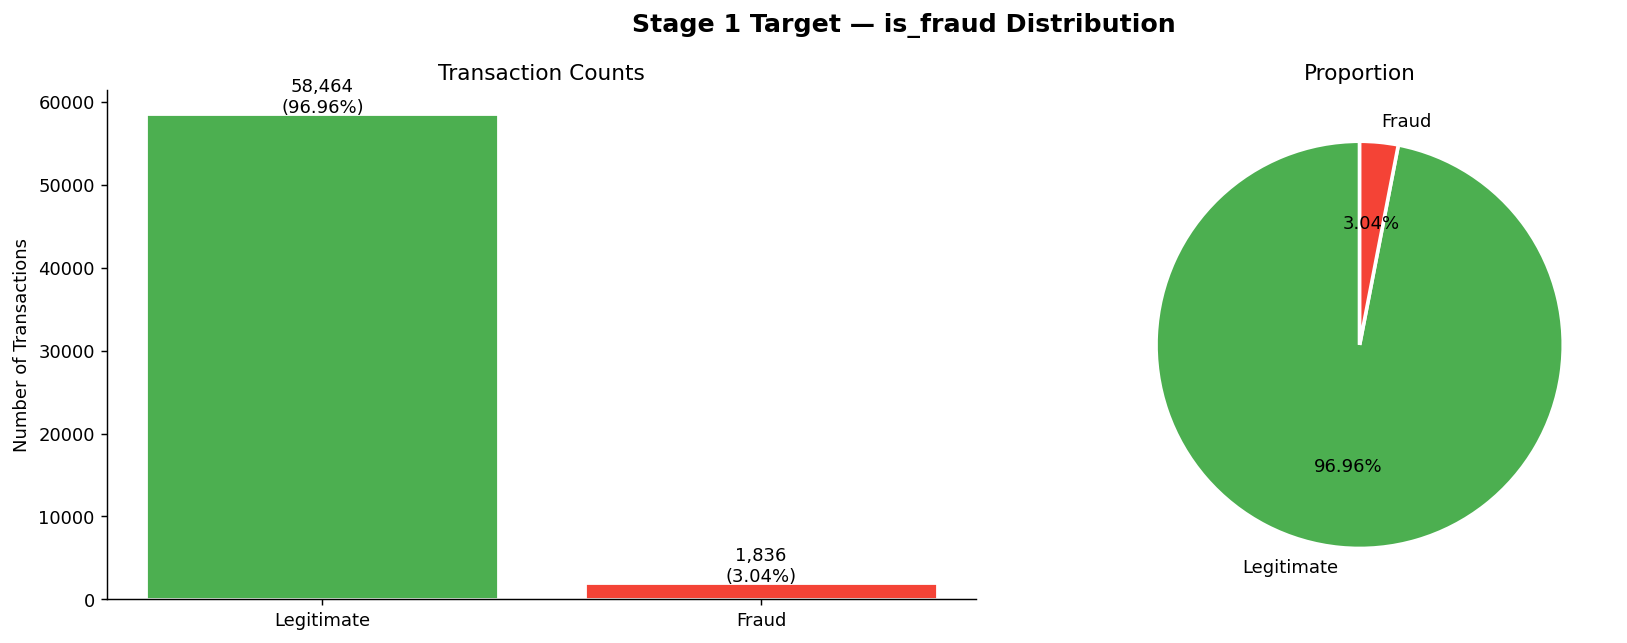

Stage 1 Distribution:
  Legitimate     :  58,464  (96.96%)
  Fraud          :   1,836  (3.04%)

Imbalance ratio: 31.8:1
(For every 1 fraud transaction there are 32 legitimate ones)

Baseline accuracy (predict all legitimate): 96.96%
This baseline catches ZERO fraud — completely useless


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Stage 1 Target — is_fraud Distribution",
             fontsize=14, fontweight="bold")

# Bar chart
counts = transactions_df["is_fraud"].value_counts().sort_index()
labels = {0: "Legitimate", 1: "Fraud"}
colors = [FRAUD_COLORS[0], FRAUD_COLORS[1]]

axes[0].bar(
    [labels[i] for i in counts.index],
    counts.values, color=colors, edgecolor="white"
)
axes[0].set_title("Transaction Counts")
axes[0].set_ylabel("Number of Transactions")
for i, (k, v) in enumerate(counts.items()):
    pct = v / len(transactions_df) * 100
    axes[0].text(i, v + 300, f"{v:,}\n({pct:.2f}%)",
                 ha="center", fontsize=10)

# Pie
axes[1].pie(
    counts.values,
    labels=[labels[i] for i in counts.index],
    autopct="%1.2f%%",
    colors=colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Proportion")

plt.tight_layout()
plt.savefig("../data/raw/stage1_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Stage 1 Distribution:")
for k, v in counts.items():
    pct = v / len(transactions_df) * 100
    print(f"  {labels[k]:<15}: {v:>7,}  ({pct:.2f}%)")

imbalance_ratio = counts[0] / counts[1]
print(f"\nImbalance ratio: {imbalance_ratio:.1f}:1")
print(f"(For every 1 fraud transaction there are "
      f"{imbalance_ratio:.0f} legitimate ones)")
print(f"\nBaseline accuracy (predict all legitimate): "
      f"{counts[0]/len(transactions_df)*100:.2f}%")
print(f"This baseline catches ZERO fraud — completely useless")

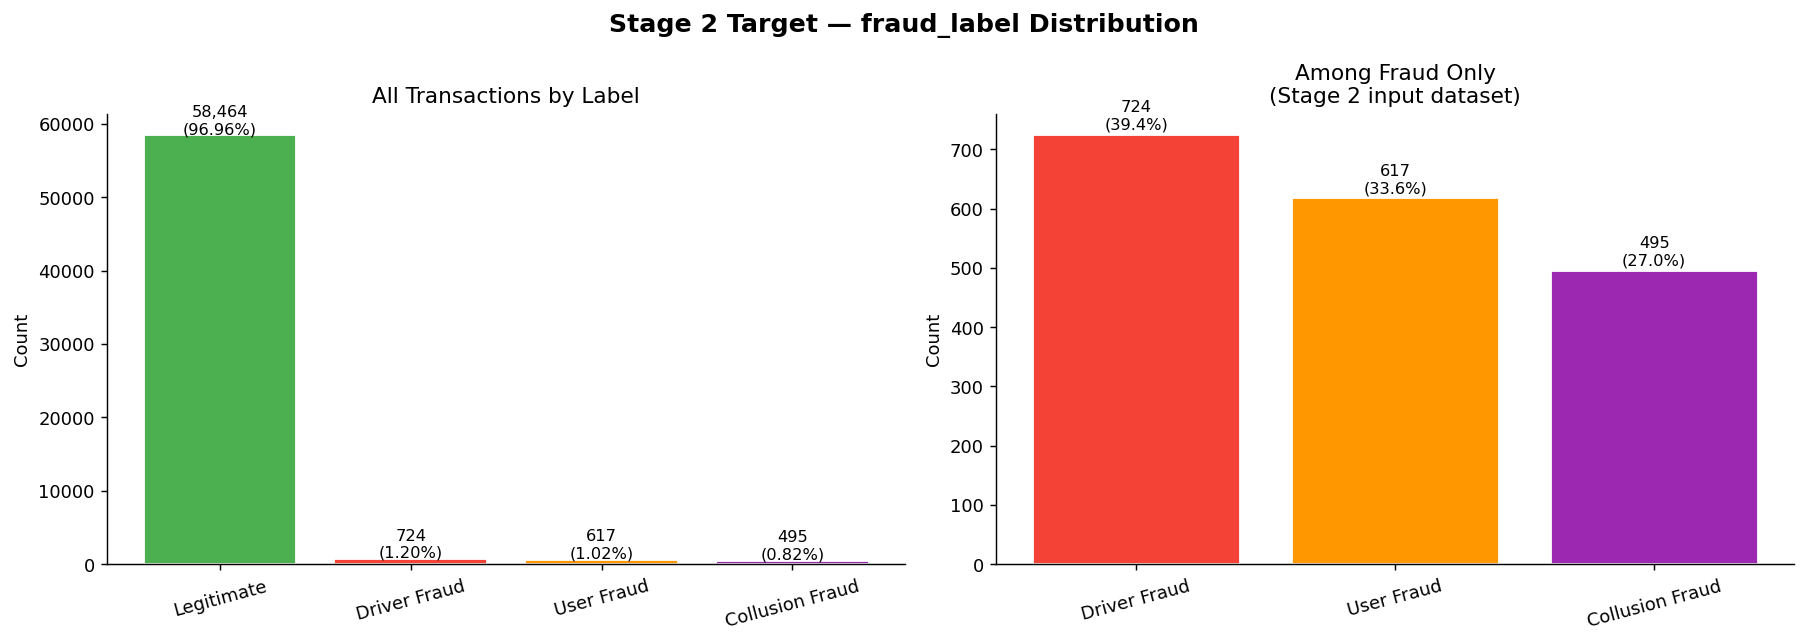

Stage 2 Distribution (fraud rows only):
  Driver Fraud      :   724  (39.4%)
  User Fraud        :   617  (33.6%)
  Collusion Fraud   :   495  (27.0%)

Total fraud rows for Stage 2: 1,836
This is the entire training set for Stage 2 model


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Stage 2 Target — fraud_label Distribution",
             fontsize=14, fontweight="bold")

all_counts = transactions_df["fraud_label"].value_counts().sort_index()
colors_all = [FRAUD_COLORS[k] for k in all_counts.index]

axes[0].bar(
    [FRAUD_LABELS[i] for i in all_counts.index],
    all_counts.values,
    color=colors_all, edgecolor="white"
)
axes[0].set_title("All Transactions by Label")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=15)
for i, (k, v) in enumerate(all_counts.items()):
    pct = v / len(transactions_df) * 100
    axes[0].text(i, v + 200, f"{v:,}\n({pct:.2f}%)",
                 ha="center", fontsize=9)

# Among fraud only — Stage 2 will only see these rows
fraud_only = transactions_df[
    transactions_df["is_fraud"] == 1
]["fraud_label"].value_counts().sort_index()

fraud_labels_filtered = {1: "Driver Fraud",
                         2: "User Fraud",
                         3: "Collusion Fraud"}
colors_fraud = [FRAUD_COLORS[k] for k in fraud_only.index]

axes[1].bar(
    [fraud_labels_filtered[i] for i in fraud_only.index],
    fraud_only.values,
    color=colors_fraud, edgecolor="white"
)
axes[1].set_title("Among Fraud Only\n(Stage 2 input dataset)")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=15)
for i, (k, v) in enumerate(fraud_only.items()):
    pct = v / fraud_only.sum() * 100
    axes[1].text(i, v + 10, f"{v:,}\n({pct:.1f}%)",
                 ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../data/raw/stage2_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Stage 2 Distribution (fraud rows only):")
for k, v in fraud_only.items():
    pct = v / fraud_only.sum() * 100
    print(f"  {fraud_labels_filtered[k]:<18}: {v:>5,}  ({pct:.1f}%)")
print(f"\nTotal fraud rows for Stage 2: {fraud_only.sum():,}")
print(f"This is the entire training set for Stage 2 model")

In [7]:
print("FRAUD SIGNAL PREVIEW\n")
print("Comparing key signals across all 4 transaction types\n")

signal_cols = [
    "completion_time_min",
    "distance_moved_km",
    "gps_signal_strength",
    "route_deviation_score",
    "claimed_speed_kmph",
    "driver_rides_today",
    "driver_user_pair_frequency",
]

for col in signal_cols:
    if col not in transactions_df.columns:
        continue
    print(f"── {col} ──")
    for label_id, label_name in FRAUD_LABELS.items():
        subset = transactions_df[
            transactions_df["fraud_label"] == label_id
        ][col].dropna()
        if len(subset) > 0:
            print(f"  {label_name:<18}: "
                  f"mean={subset.mean():>8.3f}  "
                  f"median={subset.median():>8.3f}  "
                  f"max={subset.max():>8.3f}")
    print()

FRAUD SIGNAL PREVIEW

Comparing key signals across all 4 transaction types

── completion_time_min ──
  Legitimate        : mean=  18.862  median=  12.900  max= 211.200
  Driver Fraud      : mean=   2.560  median=   1.600  max=  22.700
  User Fraud        : mean=  21.190  median=  13.900  max= 192.100
  Collusion Fraud   : mean=  11.621  median=   8.200  max=  70.000

── distance_moved_km ──
  Legitimate        : mean=   5.999  median=   4.144  max=  51.635
  Driver Fraud      : mean=   0.646  median=   0.378  max=   7.215
  User Fraud        : mean=   5.831  median=   3.792  max=  41.392
  Collusion Fraud   : mean=   5.651  median=   4.157  max=  30.620

── gps_signal_strength ──
  Legitimate        : mean=   0.825  median=   0.830  max=   0.950
  Driver Fraud      : mean=   0.980  median=   0.980  max=   1.000
  User Fraud        : mean=   0.825  median=   0.830  max=   0.950
  Collusion Fraud   : mean=   0.873  median=   0.870  max=   0.950

── route_deviation_score ──
  Legitimate 

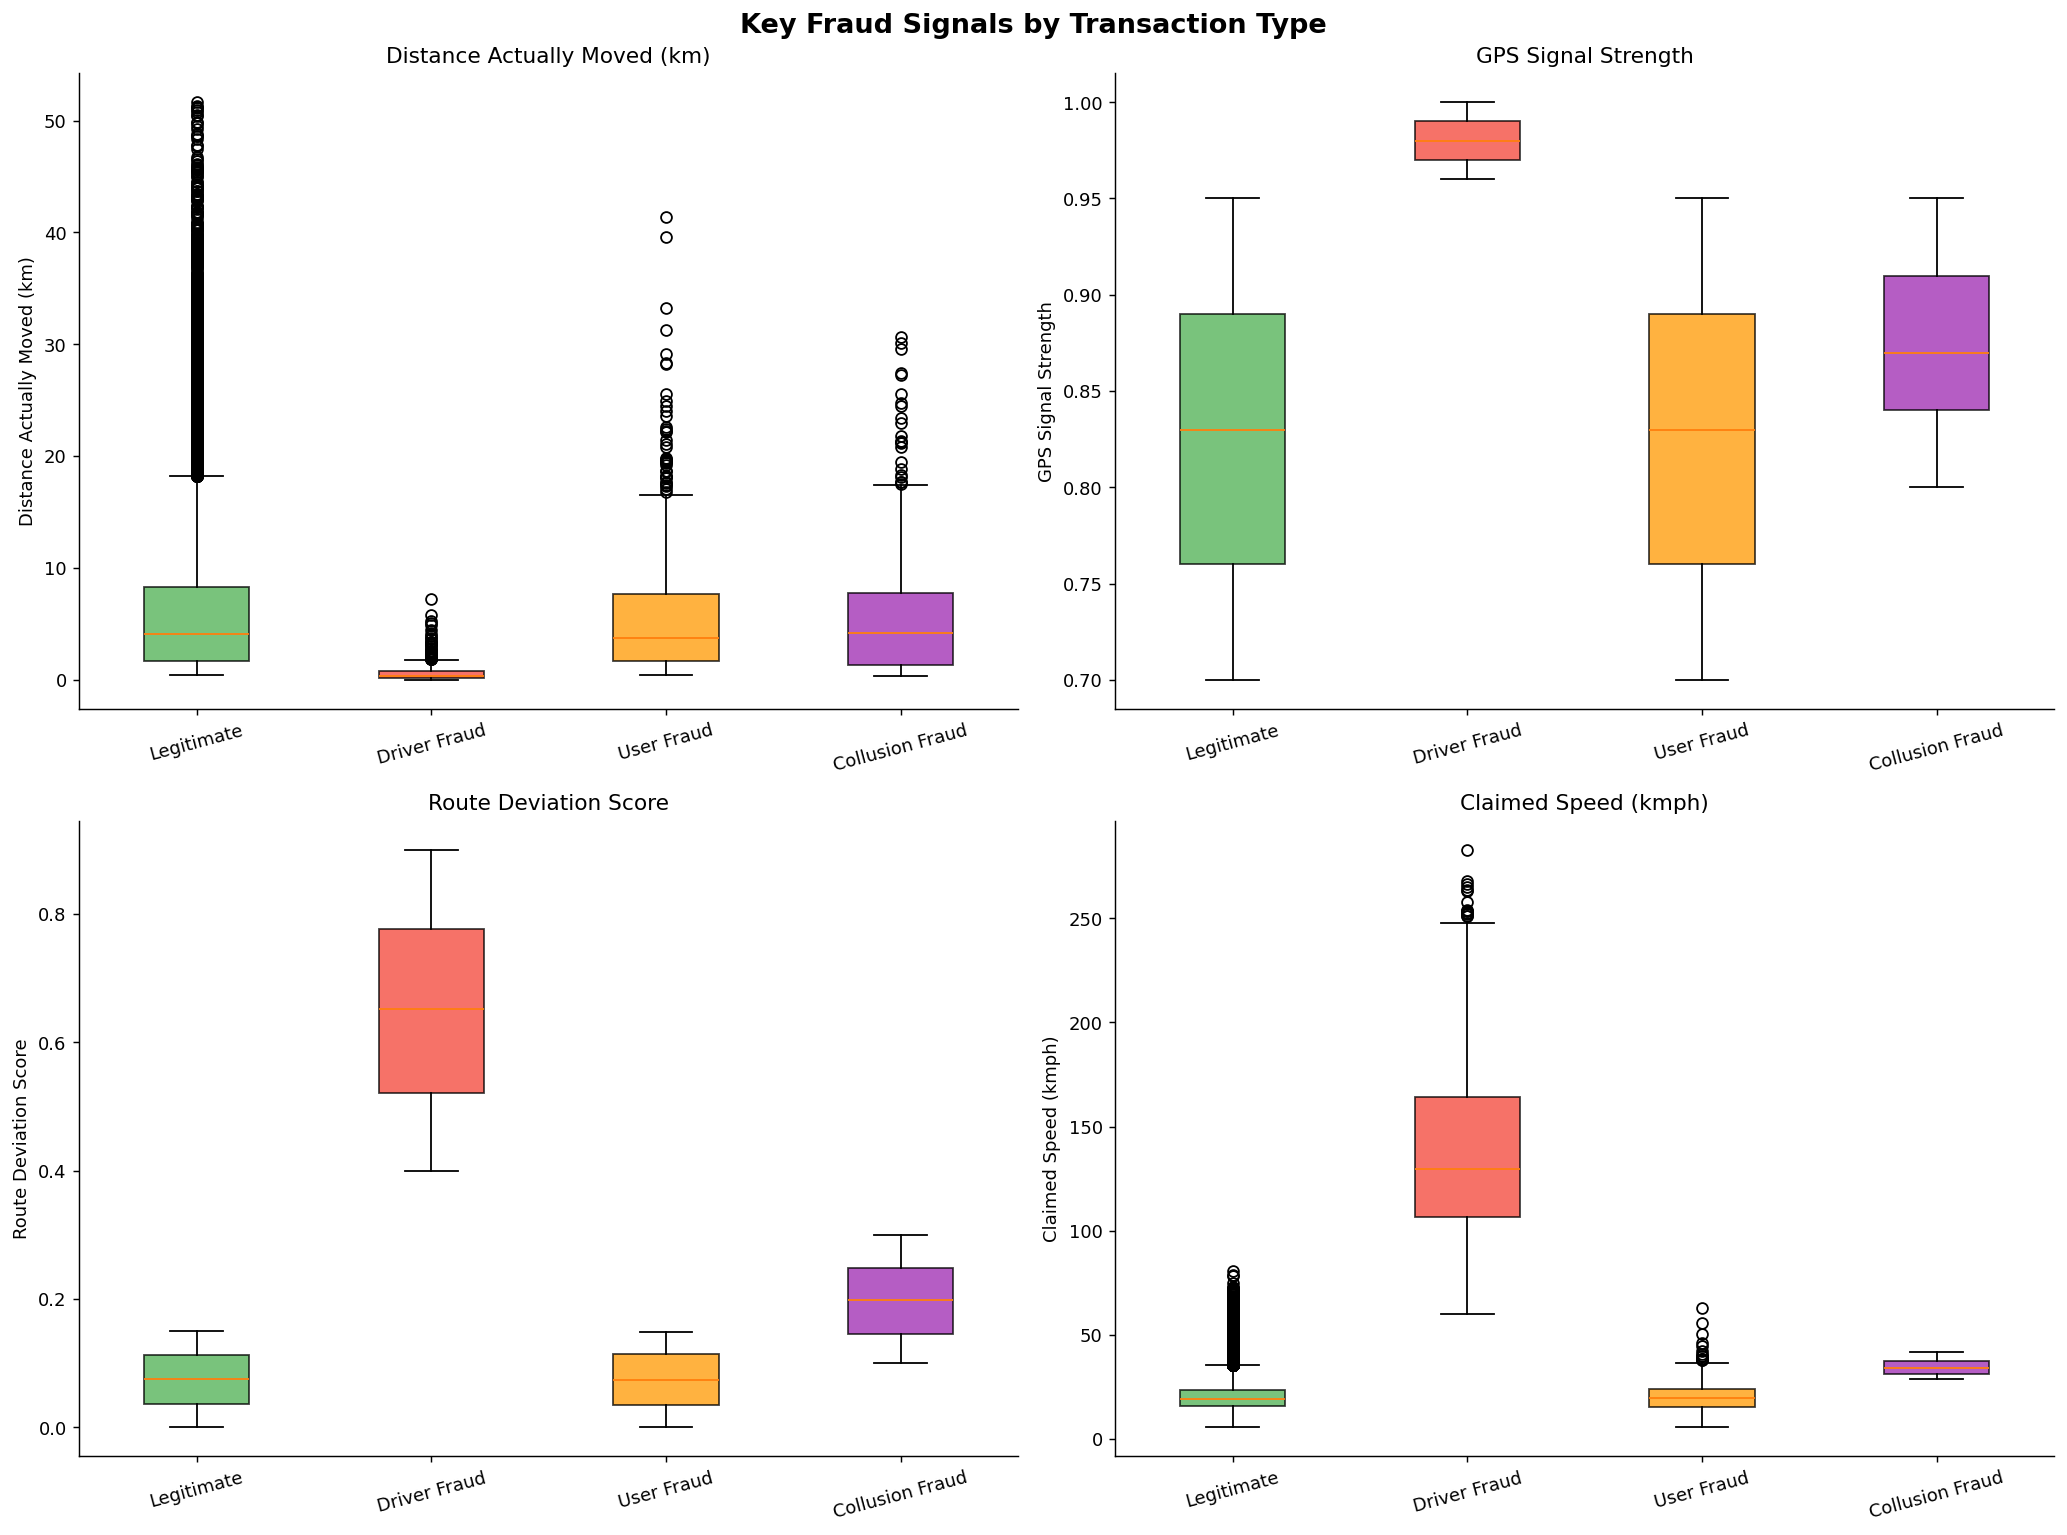

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Key Fraud Signals by Transaction Type",
             fontsize=15, fontweight="bold")

plot_signals = [
    ("distance_moved_km",    "Distance Actually Moved (km)",    axes[0][0]),
    ("gps_signal_strength",  "GPS Signal Strength",             axes[0][1]),
    ("route_deviation_score","Route Deviation Score",           axes[1][0]),
    ("claimed_speed_kmph",   "Claimed Speed (kmph)",            axes[1][1]),
]

for col, title, ax in plot_signals:
    if col not in transactions_df.columns:
        continue

    data_per_label = [
        transactions_df[
            transactions_df["fraud_label"] == k
        ][col].dropna().values
        for k in [0, 1, 2, 3]
    ]

    bp = ax.boxplot(
        data_per_label,
        patch_artist=True,
        labels=[FRAUD_LABELS[k] for k in [0,1,2,3]]
    )
    for patch, k in zip(bp["boxes"], [0,1,2,3]):
        patch.set_facecolor(FRAUD_COLORS[k])
        patch.set_alpha(0.75)

    ax.set_title(title)
    ax.set_ylabel(title)
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("../data/raw/fraud_signal_preview.png",
            dpi=150, bbox_inches="tight")
plt.show()

DEVICE RISK ANALYSIS

Device signals by transaction type:
     label_name     total  uses_vpn_pct  gps_mock_pct  multi_acct_pct
     Legitimate 58464.000         4.144         1.637           9.360
   Driver Fraud   724.000         4.420        69.475           9.392
     User Fraud   617.000        28.201        17.342          44.895
Collusion Fraud   495.000        28.687        16.566          45.657


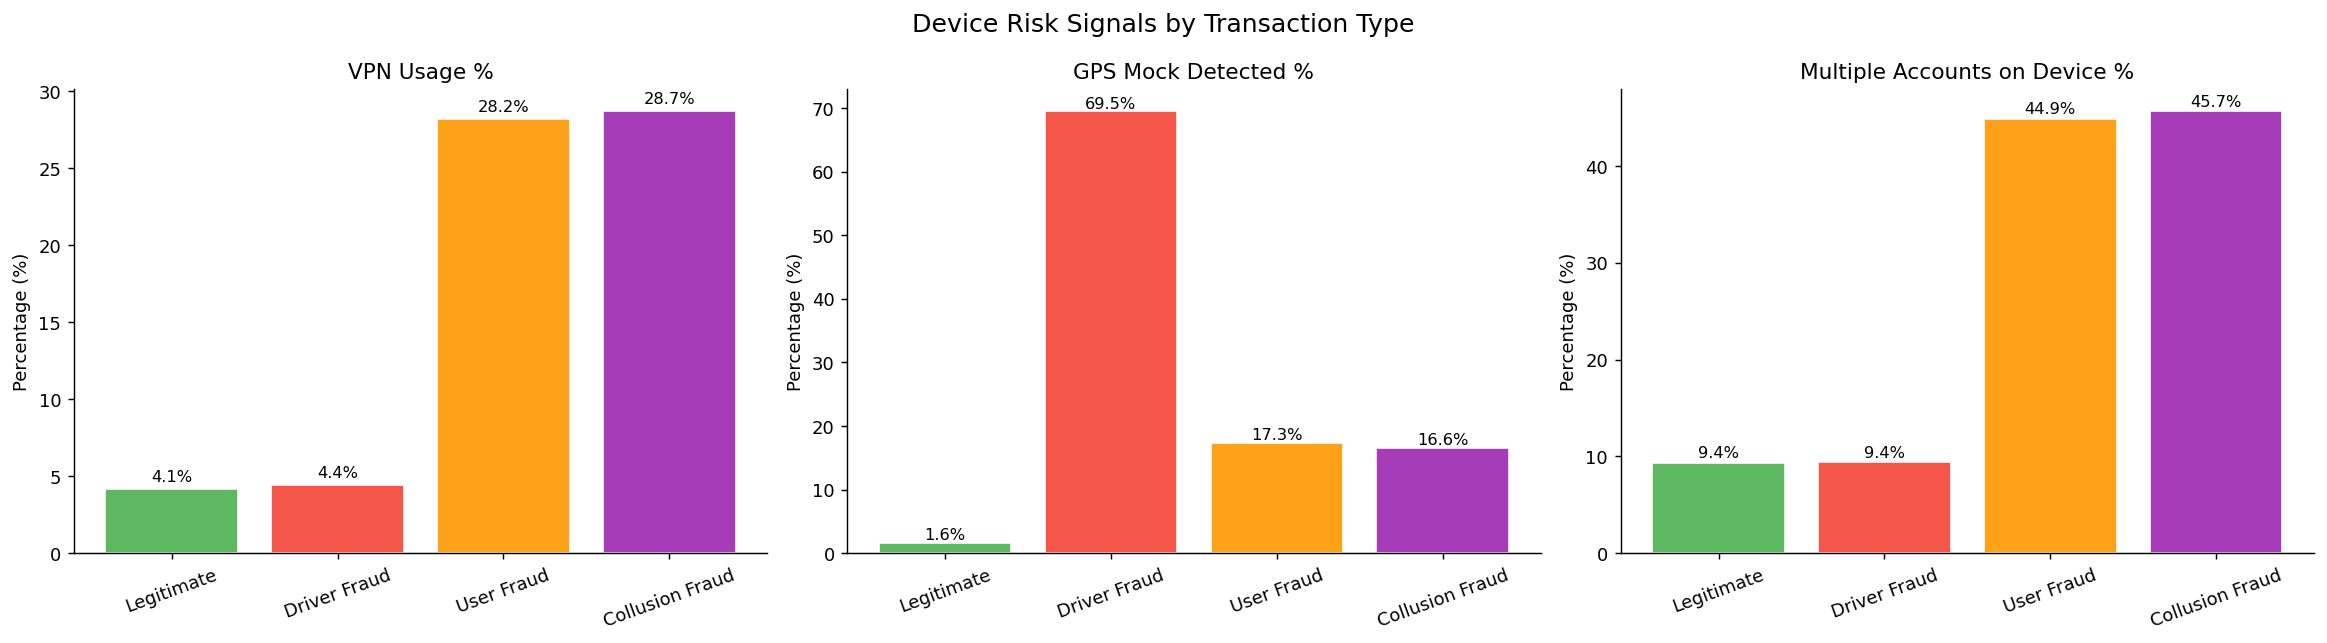

In [9]:
print("DEVICE RISK ANALYSIS\n")

device_risk_fraud = transactions_df.groupby(
    "fraud_label"
).apply(
    lambda x: pd.Series({
        "total"          : len(x),
        "uses_vpn_pct"   : x["uses_vpn"].mean() * 100,
        "gps_mock_pct"   : x["gps_mock_detected"].mean() * 100,
        "multi_acct_pct" : (x["device_accounts_linked"] > 1).mean() * 100,
    })
).reset_index()

device_risk_fraud["label_name"] = device_risk_fraud[
    "fraud_label"
].map(FRAUD_LABELS)

print("Device signals by transaction type:")
print(device_risk_fraud[[
    "label_name","total","uses_vpn_pct",
    "gps_mock_pct","multi_acct_pct"
]].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Device Risk Signals by Transaction Type", fontsize=14)

signal_names = [
    ("uses_vpn_pct",    "VPN Usage %"),
    ("gps_mock_pct",    "GPS Mock Detected %"),
    ("multi_acct_pct",  "Multiple Accounts on Device %"),
]

for idx, (col, title) in enumerate(signal_names):
    colors = [FRAUD_COLORS[k] for k in range(4)]
    axes[idx].bar(
        device_risk_fraud["label_name"],
        device_risk_fraud[col],
        color=colors, edgecolor="white", alpha=0.9
    )
    axes[idx].set_title(title)
    axes[idx].set_ylabel("Percentage (%)")
    axes[idx].tick_params(axis="x", rotation=20)
    for i, v in enumerate(device_risk_fraud[col]):
        axes[idx].text(i, v + 0.5, f"{v:.1f}%",
                       ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../data/raw/device_signals.png",
            dpi=150, bbox_inches="tight")
plt.show()

VELOCITY FEATURE ANALYSIS

Velocity = how many transactions in a short time window
High velocity from one driver/user = suspicious



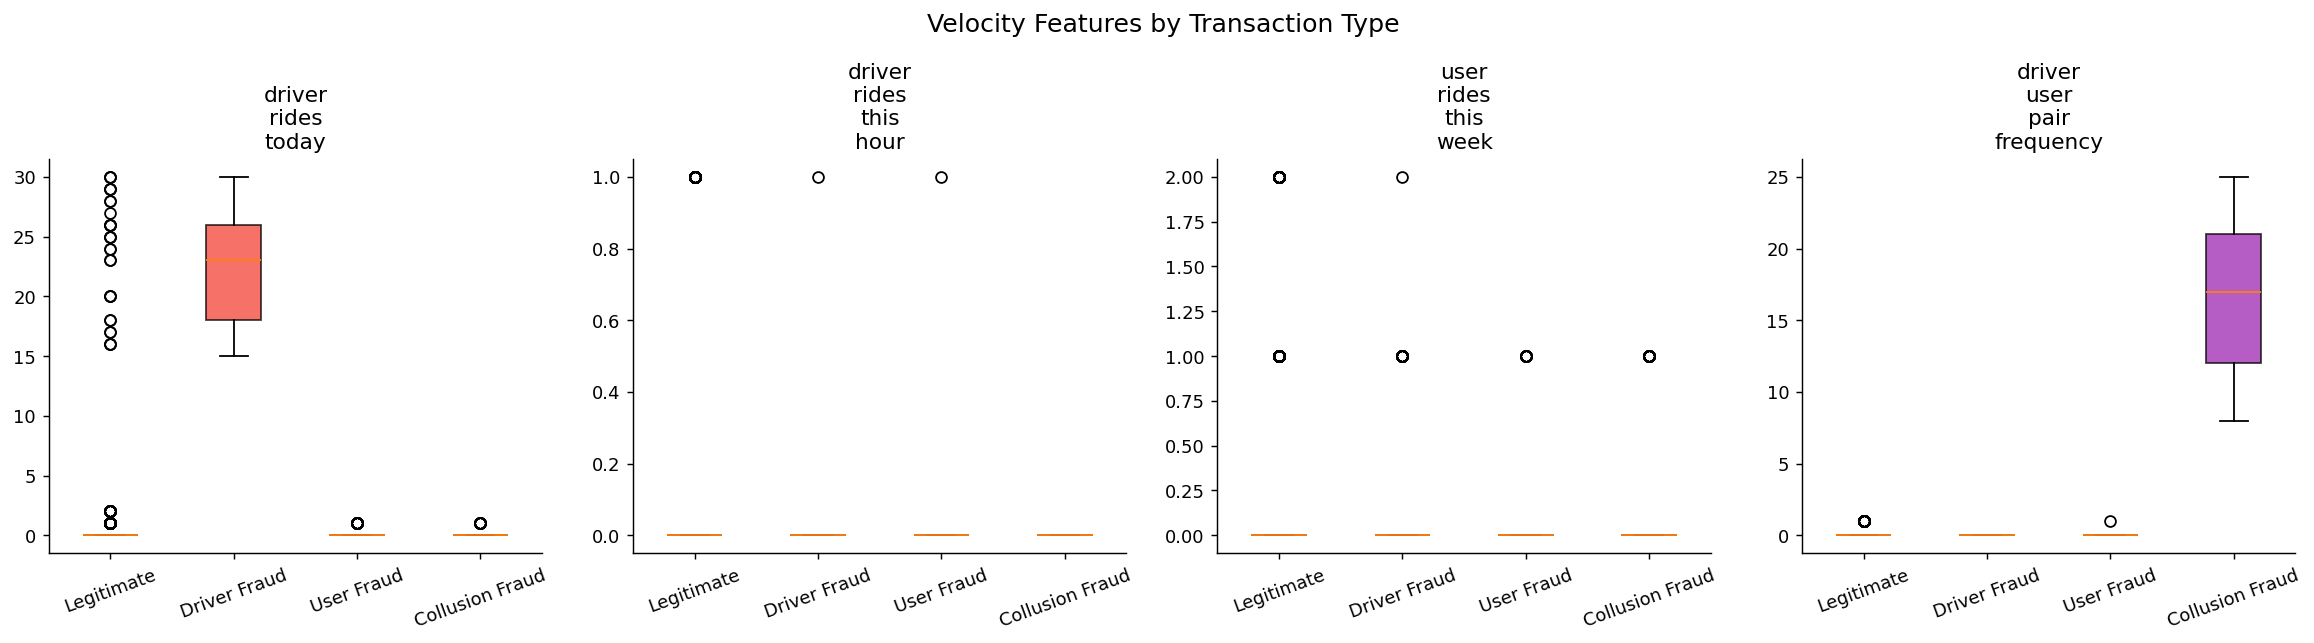

Mean velocity by transaction type:

  driver_rides_today:
    Legitimate        : 0.04
    Driver Fraud      : 22.47
    User Fraud        : 0.03
    Collusion Fraud   : 0.02

  driver_rides_this_hour:
    Legitimate        : 0.00
    Driver Fraud      : 0.00
    User Fraud        : 0.00
    Collusion Fraud   : 0.00

  user_rides_this_week:
    Legitimate        : 0.03
    Driver Fraud      : 0.04
    User Fraud        : 0.02
    Collusion Fraud   : 0.05

  driver_user_pair_frequency:
    Legitimate        : 0.00
    Driver Fraud      : 0.00
    User Fraud        : 0.00
    Collusion Fraud   : 16.64


In [10]:
print("VELOCITY FEATURE ANALYSIS\n")
print("Velocity = how many transactions in a short time window")
print("High velocity from one driver/user = suspicious\n")

velocity_cols = [
    "driver_rides_today",
    "driver_rides_this_hour",
    "user_rides_this_week",
    "driver_user_pair_frequency",
]

fig, axes = plt.subplots(1, len(velocity_cols),
                         figsize=(18, 5))
fig.suptitle("Velocity Features by Transaction Type", fontsize=14)

for idx, col in enumerate(velocity_cols):
    if col not in transactions_df.columns:
        continue

    data_per_label = [
        transactions_df[
            transactions_df["fraud_label"] == k
        ][col].dropna().values
        for k in [0, 1, 2, 3]
    ]

    bp = axes[idx].boxplot(
        data_per_label,
        patch_artist=True,
        labels=[FRAUD_LABELS[k] for k in [0,1,2,3]]
    )
    for patch, k in zip(bp["boxes"], [0,1,2,3]):
        patch.set_facecolor(FRAUD_COLORS[k])
        patch.set_alpha(0.75)

    axes[idx].set_title(col.replace("_", "\n"))
    axes[idx].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("../data/raw/velocity_signals.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Mean velocity by transaction type:")
for col in velocity_cols:
    if col not in transactions_df.columns:
        continue
    print(f"\n  {col}:")
    for k in [0, 1, 2, 3]:
        mean_val = transactions_df[
            transactions_df["fraud_label"] == k
        ][col].mean()
        print(f"    {FRAUD_LABELS[k]:<18}: {mean_val:.2f}")

In [11]:
print("\n DUPLICATE ROW DETECTION\n")
for name, df in tables.items():
    dupe_count = df.duplicated().sum()
    pct        = round(dupe_count / len(df) * 100, 3)
    print(f"  {name:<15}: {dupe_count:>5} duplicates  ({pct}%)")

print()
summary_rows = []
for name, df in tables.items():
    summary_rows.append({
        "table"      : name,
        "rows"       : len(df),
        "columns"    : len(df.columns),
        "null_cells" : df.isnull().sum().sum(),
        "duplicates" : df.duplicated().sum(),
    })

summary_df = pd.DataFrame(summary_rows)
print("\n FINAL DATA SUMMARY\n")
print(summary_df.to_string(index=False))


 DUPLICATE ROW DETECTION

  transactions   :   300 duplicates  (0.498%)
  drivers        :     0 duplicates  (0.0%)
  users          :   200 duplicates  (0.99%)
  devices        :     0 duplicates  (0.0%)


 FINAL DATA SUMMARY

       table  rows  columns  null_cells  duplicates
transactions 60300       48       57869         300
     drivers  3000       18         644           0
       users 20200       19       14141         200
     devices 22000       10        5771           0
